# 📊 Project Introduction

In this project, we will begin analyzing the **Olist E-commerce dataset**.  
The data consists of **9 relational tables**.  

To ensure **high performance** and maintain a clear, efficient workflow, we will perform the **merging process in several stages**.  

This approach allows us to:
- Create specific tables tailored for different **Exploratory Data Analysis (EDA)** phases.
- Make the analysis more manageable.
- Ensure accurate insights from the data.


In [160]:
# Invoke the necessary libraries for the project:

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [161]:
# Load Data 

customers = pd.read_csv("../Data/olist_customers_dataset.csv")
geo = pd.read_csv("../Data/olist_geolocation_dataset.csv")
order_items = pd.read_csv("../Data/olist_order_items_dataset.csv")
payments = pd.read_csv("../Data/olist_order_payments_dataset.csv")
reviews = pd.read_csv("../Data/olist_order_reviews_dataset.csv")
orders = pd.read_csv("../Data/olist_orders_dataset.csv")
products = pd.read_csv("../Data/olist_products_dataset.csv")
sellers = pd.read_csv("../Data/olist_sellers_dataset.csv")
categories = pd.read_csv("../Data/product_category_name_translation.csv")

In [162]:
# Display a sample of all data 
data = {
    "Customers" : customers,
    "Geolocation" : geo,
    "Orders Items" : order_items,
    "Payments" : payments,
    "Reviews" : reviews,
    "Orders" : orders,
    "Products" : products,
    "Sellers" : sellers,
    "Categories" : categories
}
for name,df in data.items():
    print(f"Table: {name}:\n")
    display(df.head()) 
    print("\n")
    print("Shape:", df.shape)
    print("="*50)
    print("\n")
    

Table: Customers:



,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP




Shape: (99441, 5)


Table: Geolocation:



,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP




Shape: (1000163, 5)


Table: Orders Items:



...



Shape: (32951, 9)


Table: Sellers:



,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP




Shape: (3095, 4)


Table: Categories:



,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor




Shape: (71, 2)




In [163]:
# After loading and displaying the datasets, 
# we will perform multiple merges to combine them 
# and create a unified dataset for extracting insightful information.


"""
First merge (Sales & Products Analysis):
    by merge orders - order_items - products - categories
"""

# 1- Merge between products and categories

# Before merging i want to clean The linking column in each of the two tables(products,category)

products["product_category_name"] = products["product_category_name"].str.strip().str.lower() 
categories["product_category_name"] = categories["product_category_name"].str.strip().str.lower()

prod_cate_df = pd.merge(products, categories, on = "product_category_name", how = "left")

orders_items_df = pd.merge(orders, order_items, on = "order_id", how = "inner")

master_sales = pd.merge(orders_items_df, prod_cate_df, on = "product_id", how = "inner")



In [164]:
# After we doing the first merge let's clean this data 

# Create Functions To Ease handle with data cleaning

# ==============================
# 1- Check Missing Values
# ==============================

def check_missing(df):
    missing_count = df.isnull().sum()
    missing_percent = (missing_count / len(df)) * 100

    report = pd.DataFrame({
        "Missing Values": missing_count,
        "Percentage %": missing_percent.round(2)
    })

    report = report.sort_values(by="Percentage %", ascending=False)

    filtered_report = report[report["Missing Values"] > 0]

    return filtered_report if not filtered_report.empty else "No missing values in this dataset"



# ==============================
# 2- Check Data Types + Unique + Sample
# ==============================

def check_dtypes(df):
    sample_values = []

    for col in df.columns:
        first_valid = df[col].first_valid_index()
        if first_valid is not None:
            sample_values.append(df.loc[first_valid, col])
        else:
            sample_values.append(None)

    report = pd.DataFrame({
        "Column Name": df.columns,
        "Data Type": df.dtypes.values,
        "Unique Values": df.nunique().values,
        "Sample Value": sample_values
    })

    return report


# ==============================
# 3- Detect Outliers Using IQR
# ==============================

def detect_outliers_iqr(df, exclude_cols=None):
    if exclude_cols is None:
        exclude_cols = []

    numeric_cols = df.select_dtypes(include=['int64', 'float64'])
    numeric_cols = numeric_cols.drop(columns=exclude_cols, errors='ignore')

    outlier_report = {}

    for col in numeric_cols.columns:
        Q1 = numeric_cols[col].quantile(0.25)
        Q3 = numeric_cols[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers_count = (
            (numeric_cols[col] < lower_bound) |
            (numeric_cols[col] > upper_bound)
        ).sum()

        if outliers_count > 0:
            outlier_report[col] = {
                "Outliers Count": int(outliers_count),
                "Lower Bound": round(lower_bound, 2),
                "Upper Bound": round(upper_bound, 2)
            }

    return outlier_report if outlier_report else "No outliers detected"



# ==============================
# 4- Check Duplicate Primary Key
# ==============================

def check_duplicate_pk(df, pk_column):
    duplicates = df[df.duplicated(subset=[pk_column], keep=False)]

    if not duplicates.empty:
        return {
            "Duplicate PK Count": len(duplicates),
            "Duplicate Rows": duplicates.sort_values(by=pk_column)
        }

    return "No duplicate values in primary keys"



# ==============================
# 5-- Check Fully Duplicate Rows
# ==============================

def check_duplicate_rows(df):
    duplicate_rows = df[df.duplicated(keep=False)]

    if not duplicate_rows.empty:
        return {
            "Duplicate Rows Count": len(duplicate_rows),
            "Duplicate Rows": duplicate_rows
        }

    return "No duplicate rows found"



# ==============================
# 6- Full Data Quality Report (Wrapper)
# ==============================

def full_data_quality_report(df, pk_column=None):
    print("========== DATA QUALITY REPORT ==========\n")

    print("1️⃣➡️ Missing Values:")
    print(check_missing(df), "\n")

    print("2️⃣➡️ Data Types & Summary:")
    print(check_dtypes(df), "\n")

    print("3️⃣➡️ Outliers (IQR Method):")
    print(detect_outliers_iqr(df), "\n")

    if pk_column:
        print("4️⃣➡️ Duplicate Primary Keys:")
        print(check_duplicate_pk(df, pk_column), "\n")

    print("5️⃣➡️ Fully Duplicate Rows:")
    print(check_duplicate_rows(df), "\n")

    print("========== END OF REPORT ==========")

In [165]:
# check data quality of masters sales 

full_data_quality_report(master_sales)
shape = master_sales.shape
print(f"This Data Contain:\n{shape[0]} rows and {shape[1]} columns")


========== DATA QUALITY REPORT ==========

1️⃣➡️ Missing Values:
                               Missing Values  Percentage %
order_delivered_customer_date            2454          2.18
product_category_name_english            1627          1.44
product_category_name                    1603          1.42
product_photos_qty                       1603          1.42
product_name_lenght                      1603          1.42
product_description_lenght               1603          1.42
order_delivered_carrier_date             1194          1.06
product_width_cm                           18          0.02
product_height_cm                          18          0.02
product_length_cm                          18          0.02
product_weight_g                           18          0.02
order_approved_at                          15          0.01 

2️⃣➡️ Data Types & Summary:
                      Column Name Data Type  Unique Values  \
0                        order_id    object          98666   
1

In [166]:
# After show our report let's clean data 

# 1. Replacing missing values ​​in English names
master_sales['product_category_name_english'] = master_sales['product_category_name_english'].fillna('others')


# 2. Delete the Portuguese names column

master_sales.drop(columns= ['product_category_name'], inplace = True)

# 3. Delete the rows that have missing values ​​in dimensions and weights (because they are very few)

master_sales.dropna(subset=['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm'], inplace=True)


# 4. Delete columns that we do not need in the analysis (technical columns)

cols_to_drop = ['product_name_lenght', 'product_description_lenght', 'product_photos_qty']
master_sales.drop(columns=cols_to_drop, inplace=True, errors='ignore')

#5. Converting the data type to date columns.

date_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

for col in date_cols:
    master_sales[col] = pd.to_datetime(master_sales[col], errors='coerce')


# 6. Clean up illogical values ​​in dimensions and weights (must be greater than zero)

master_sales = master_sales[
    (master_sales['product_weight_g'] > 0) & 
    (master_sales['product_length_cm'] > 0) & 
    (master_sales['product_height_cm'] > 0) & 
    (master_sales['product_width_cm'] > 0)
]


#7. Price cleaning (must be greater than zero)

master_sales = master_sales[master_sales['price'] > 0]

#8- create total order cost in mastes sales table 

master_sales["total_order_cost"] = master_sales["price"] + master_sales["freight_value"]

#9. total orders cost cleaning (must be greater than zero) 

master_sales = master_sales[master_sales["total_order_cost"] >0]


In [167]:
# Check Data Quality Again

full_data_quality_report(master_sales)

========== DATA QUALITY REPORT ==========

1️⃣➡️ Missing Values:
                               Missing Values  Percentage %
order_delivered_customer_date            2454          2.18
order_delivered_carrier_date             1194          1.06
order_approved_at                          15          0.01 

2️⃣➡️ Data Types & Summary:
                      Column Name       Data Type  Unique Values  \
0                        order_id          object          98644   
1                     customer_id          object          98644   
2                    order_status          object              7   
3        order_purchase_timestamp  datetime64[ns]          98090   
4               order_approved_at  datetime64[ns]          90156   
5    order_delivered_carrier_date  datetime64[ns]          81002   
6   order_delivered_customer_date  datetime64[ns]          95642   
7   order_estimated_delivery_date  datetime64[ns]            450   
8                   order_item_id           int64    

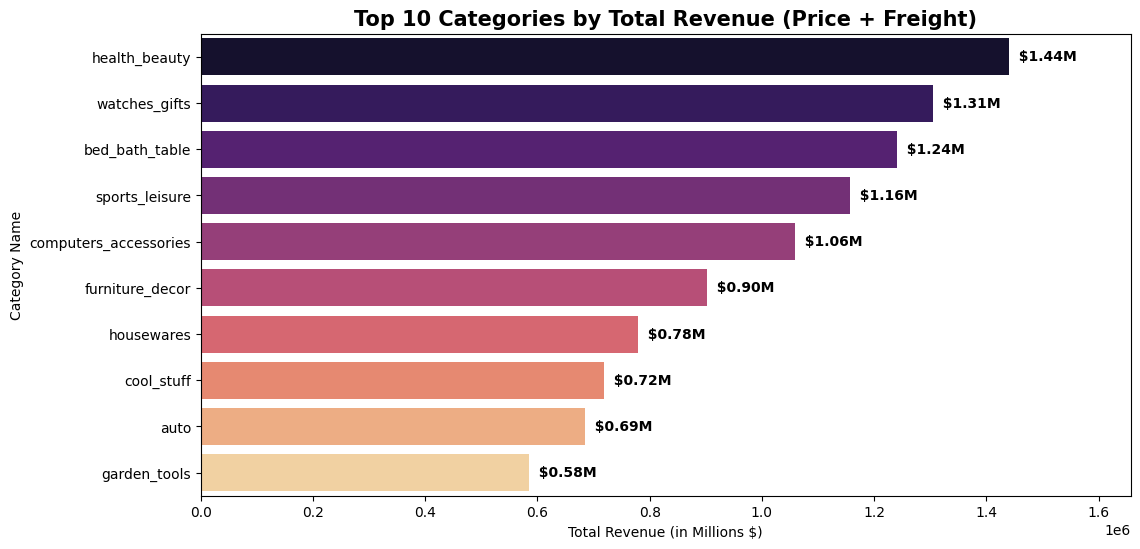

In [168]:
# Now it's Time to Exploratory Data Analysis

# 1- Calculate total revenue for each category


top_revenue_cats = master_sales.groupby('product_category_name_english')['total_order_cost'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=top_revenue_cats.values, 
    y=top_revenue_cats.index,
    hue=top_revenue_cats.index,
    palette="magma",
    legend=False
)

for i, v in enumerate(top_revenue_cats.values):
    ax.text(v, i, f'  ${v/1e6:.2f}M', va='center', fontweight='bold', color='black')

ax.set_title('Top 10 Categories by Total Revenue (Price + Freight)', fontsize=15, fontweight='bold')
ax.set_xlabel('Total Revenue (in Millions $)')
ax.set_ylabel("Category Name")

plt.xlim(0, top_revenue_cats.values.max() * 1.15)

plt.show()

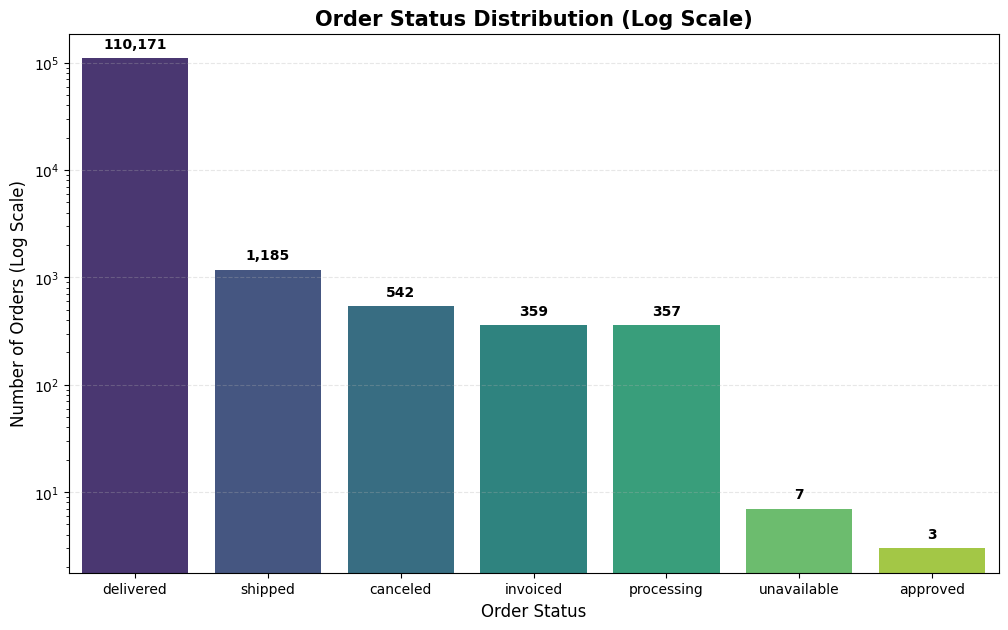

In [169]:
#2. Order Status Distribution Analysis


status_counts = master_sales['order_status'].value_counts().reset_index()
status_counts.columns = ['Status', 'Count']

fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(data=status_counts, x='Status', y='Count', hue='Status', 
            palette='viridis', legend=False, ax=ax)

ax.set_yscale('log')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(format(height, ',.0f'), 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 10), 
                    textcoords='offset points',
                    fontsize=10,
                    fontweight='bold')

ax.set_title('Order Status Distribution (Log Scale)', fontsize=15, fontweight='bold')
ax.set_xlabel('Order Status', fontsize=12)
ax.set_ylabel('Number of Orders (Log Scale)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

<Figure size 1400x700 with 0 Axes>

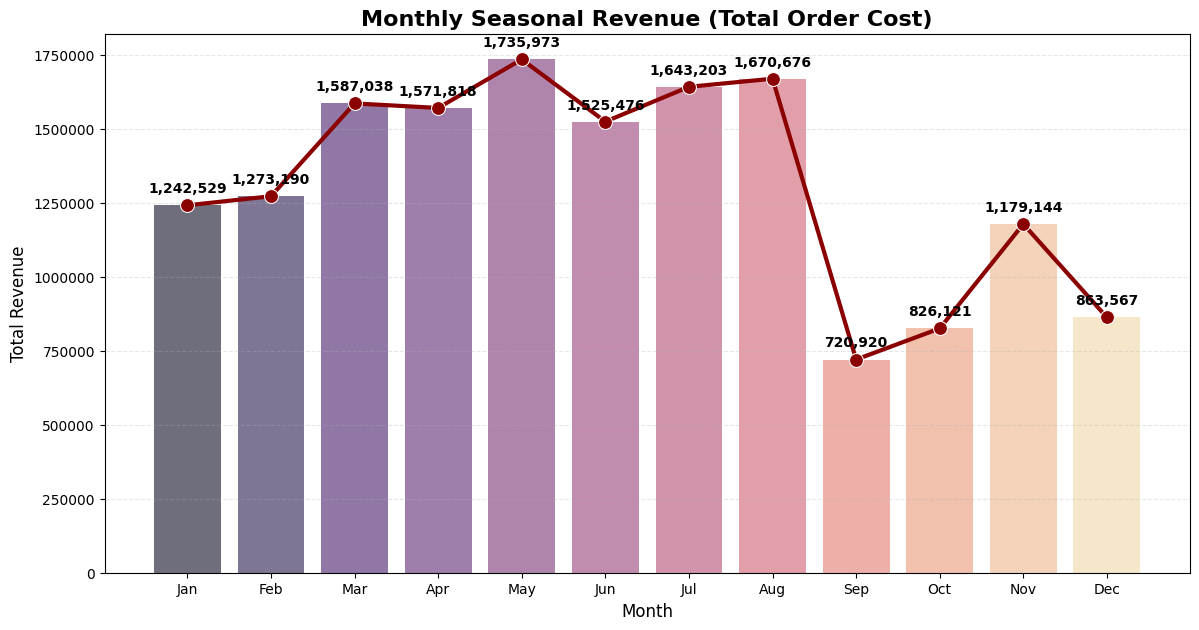

In [170]:
#3- Seasonal monthly revenues


master_sales['month_name'] = master_sales['order_purchase_timestamp'].dt.strftime('%b')
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

seasonal_revenue = master_sales.groupby('month_name')['total_order_cost'].sum().reindex(month_order).reset_index()

plt.figure(figsize=(14, 7))
fig, ax = plt.subplots(figsize=(14, 7))

sns.barplot(data=seasonal_revenue, x='month_name', y='total_order_cost', 
            hue='month_name', palette='magma', alpha=0.6, legend=False, ax=ax)

sns.lineplot(data=seasonal_revenue, x=range(len(month_order)), y='total_order_cost', 
             marker='o', color='darkred', linewidth=3, markersize=10, ax=ax)

for p in ax.patches:
    ax.annotate(format(p.get_height(), ',.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 12), 
                textcoords='offset points',
                fontsize=10, fontweight='bold')

ax.set_title('Monthly Seasonal Revenue (Total Order Cost)', fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Revenue', fontsize=12)
ax.ticklabel_format(style='plain', axis='y') 
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

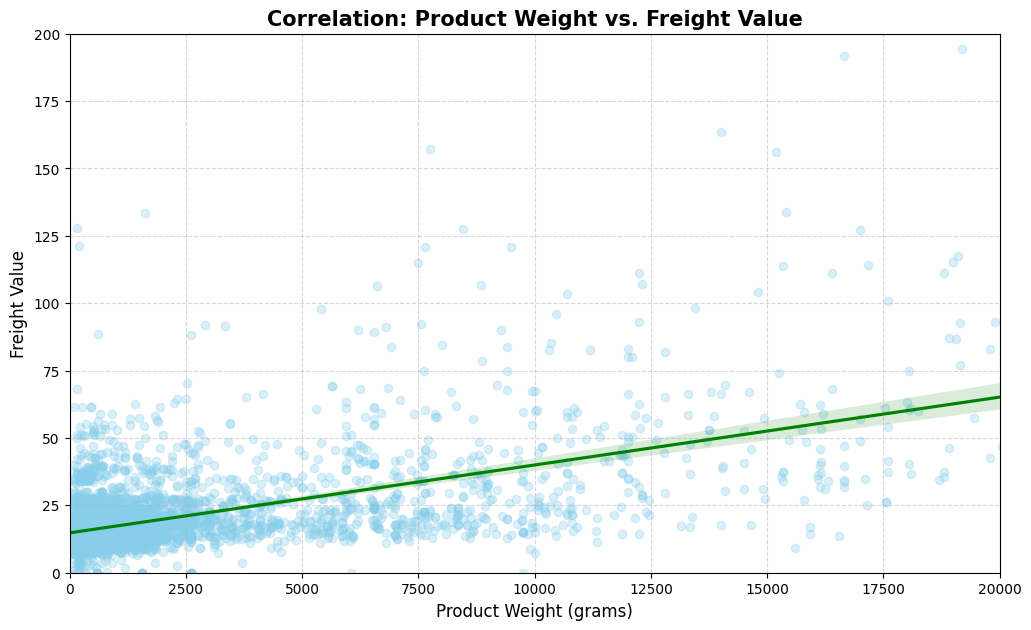

Correlation Coefficient: 0.61


In [171]:
#4. The relationship between product weight and shipping cost (Weight vs. Freight)


sample_data = master_sales.sample(n=5000, random_state=42)

fig, ax = plt.subplots(figsize=(12, 7))

sns.regplot(data=sample_data, x='product_weight_g', y='freight_value', 
            scatter_kws={'alpha':0.3, 'color':'skyblue'}, 
            line_kws={'color':'green'}, ax=ax)

ax.set_title('Correlation: Product Weight vs. Freight Value', fontsize=15, fontweight='bold')
ax.set_xlabel('Product Weight (grams)', fontsize=12)
ax.set_ylabel('Freight Value', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)

ax.set_xlim(0, 20000) 
ax.set_ylim(0, 200) 

plt.show()

correlation = master_sales['product_weight_g'].corr(master_sales['freight_value'])
print(f"Correlation Coefficient: {correlation:.2f}")

In [172]:
# the secode merge it's about customet behavior by merge customer table with master table 

sales = master_sales.copy()

cus_sales = pd.merge(sales,customers,on= "customer_id", how = "inner") 

In [173]:
# check quality of cus_sales

full_data_quality_report(cus_sales)

========== DATA QUALITY REPORT ==========

1️⃣➡️ Missing Values:
                               Missing Values  Percentage %
order_delivered_customer_date            2454          2.18
order_delivered_carrier_date             1194          1.06
order_approved_at                          15          0.01 

2️⃣➡️ Data Types & Summary:
                      Column Name       Data Type  Unique Values  \
0                        order_id          object          98644   
1                     customer_id          object          98644   
2                    order_status          object              7   
3        order_purchase_timestamp  datetime64[ns]          98090   
4               order_approved_at  datetime64[ns]          90156   
5    order_delivered_carrier_date  datetime64[ns]          81002   
6   order_delivered_customer_date  datetime64[ns]          95642   
7   order_estimated_delivery_date  datetime64[ns]            450   
8                   order_item_id           int64    

Total Unique Customers: 95,401
Customers Who Bought More Than Once: 2,910
Retention Rate: 3.05%


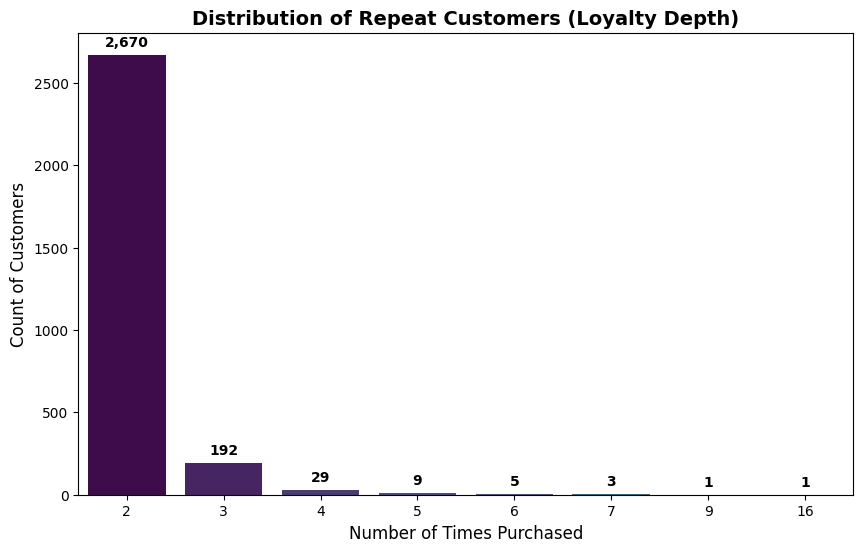

In [174]:
# the data cus_sales is clean not to need any operator to do in it

# Now let's do exploratory data analysis in cus_sales

# The most important question for the client: How many second referral clients?


#1- calculate orders count per unique customers

customer_orders =cus_sales.groupby("customer_unique_id")['order_id'].nunique().reset_index()

customer_orders.columns = ['customer_unique_id', "order_count"]

# 1.1- Dividing customers into (one-time) and (more than once)

repeat_customer_count = customer_orders[customer_orders["order_count"]>1].shape[0]
one_time_customer_count = customer_orders[customer_orders["order_count"]==1].shape[0]
total_unique_customers = customer_orders.shape[0]

# 1.2- Calculating Percentages

rate = (repeat_customer_count/total_unique_customers)*100

print(f"Total Unique Customers: {total_unique_customers:,}")
print(f"Customers Who Bought More Than Once: {repeat_customer_count:,}")
print(f"Retention Rate: {rate:.2f}%")

#1.3- Filtering customers who have purchased more than once

repeat_behavior = customer_orders[customer_orders['order_count']>1]['order_count'].value_counts().reset_index()
repeat_behavior.columns = ['Nu_of_Orders', 'Nu_of_Customers']

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=repeat_behavior.head(10), 
    x="Nu_of_Orders", 
    y="Nu_of_Customers", 
    hue="Nu_of_Orders", 
    palette="viridis", 
    legend=False
)

#1.4-  Add numbers above the columns

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(format(height, ',.0f'), 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points', 
                    fontweight='bold')

ax.set_title('Distribution of Repeat Customers (Loyalty Depth)', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Times Purchased', fontsize=12)
ax.set_ylabel('Count of Customers', fontsize=12)

plt.show()

In [175]:
# 2. Calculate revenue and number of orders for each state

state_analysis = cus_sales.groupby('customer_state').agg({
    'total_order_cost': 'sum', 
    'order_id': 'nunique'
}).sort_values(ascending=False, by='total_order_cost').reset_index()

state_analysis.columns = ['State', 'Total_Revenue', 'Total_Orders']

# 3. Calculate the average order value in each state (AOV)
state_analysis['AOV'] = state_analysis['Total_Revenue'] / state_analysis['Total_Orders']

print("--- Top 10 States by Revenue & AOV ---")
print(state_analysis.head(10))




--- Top 10 States by Revenue & AOV ---
  State  Total_Revenue  Total_Orders         AOV
0    SP     5921354.69         41370  143.131610
1    RJ     2129638.46         12761  166.886487
2    MG     1856020.35         11541  160.819717
3    RS      883603.95          5429  162.756300
4    PR      800794.30          4996  160.287090
5    BA      611258.97          3357  182.084888
6    SC      609862.86          3610  168.937080
7    DF      353184.39          2124  166.282669
8    GO      347433.43          2005  173.283506
9    ES      324801.91          2025  160.396005


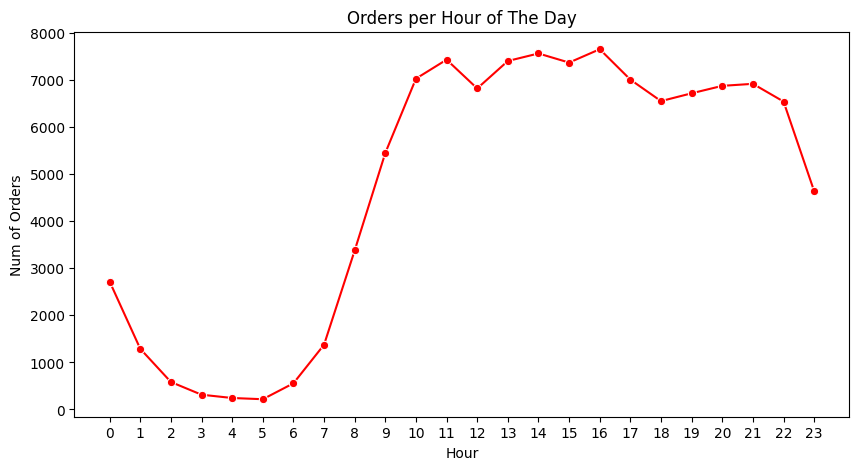

In [176]:
#3- Purchase Hour Analysis

# extract hour from order_purchase_timestamp coulmn

cus_sales["Hour"] = cus_sales["order_purchase_timestamp"].dt.hour

# count of orders for each hour

orders_per_hour = cus_sales.groupby("Hour")["order_id"].count().reset_index()

# plot line chart

plt.figure(figsize=(10,5))

sns.lineplot(data=orders_per_hour, x= "Hour", y= "order_id", marker="o", color="red")

plt.title("Orders per Hour of The Day")
plt.xlabel=("Hours")
plt.ylabel("Num of Orders")
plt.xticks(range(0,24))
plt.show()

In [177]:
#4- Calculate Revenue and orders of each city

cus_sales["total_order_cost"] = cus_sales["price"] + cus_sales["freight_value"]

city_analysis = cus_sales.groupby("customer_city").agg({
    "total_order_cost" : "sum",
    "order_id" : "nunique"
}).sort_values(ascending=False, by="total_order_cost").reset_index()

city_analysis.columns = ["City", "Total_Revenue", "Total_Orders"]


# Calculating the Average Order Value (AOV)

city_analysis["AOV"] = city_analysis["Total_Revenue"] / city_analysis["Total_Orders"]

print("--- Top 10 Cities by Revenue & AOV ---")
print(city_analysis.head(10))

--- Top 10 Cities by Revenue & AOV ---
             City  Total_Revenue  Total_Orders         AOV
0       sao paulo     2170082.73         15401  140.905313
1  rio de janeiro     1154190.50          6833  168.914167
2  belo horizonte      416679.29          2749  151.574860
3        brasilia      352260.09          2115  166.553234
4        curitiba      244739.87          1510  162.079384
5    porto alegre      221994.89          1370  162.040066
6        salvador      216772.40          1238  175.098869
7        campinas      212541.70          1429  148.734570
8       guarulhos      163575.82          1178  138.858930
9         niteroi      137919.38           845  163.218201


In [178]:
# third merge it will be between (cus_sales,payments)

sales_two = cus_sales.copy()

pay_sales = pd.merge(sales_two, payments, on="order_id", how = "inner")

# check pay_sales quality

full_data_quality_report(pay_sales)

========== DATA QUALITY REPORT ==========

1️⃣➡️ Missing Values:
                               Missing Values  Percentage %
order_delivered_customer_date            2567          2.18
order_delivered_carrier_date             1245          1.06
order_approved_at                          15          0.01 

2️⃣➡️ Data Types & Summary:
                      Column Name       Data Type  Unique Values  \
0                        order_id          object          98643   
1                     customer_id          object          98643   
2                    order_status          object              7   
3        order_purchase_timestamp  datetime64[ns]          98089   
4               order_approved_at  datetime64[ns]          90155   
5    order_delivered_carrier_date  datetime64[ns]          81001   
6   order_delivered_customer_date  datetime64[ns]          95641   
7   order_estimated_delivery_date  datetime64[ns]            449   
8                   order_item_id           int64    

In [179]:
# Remove negative values in pay_sales

payment_sales = pay_sales[(pay_sales['payment_installments'] > 0) & (pay_sales['payment_value'] > 0)]

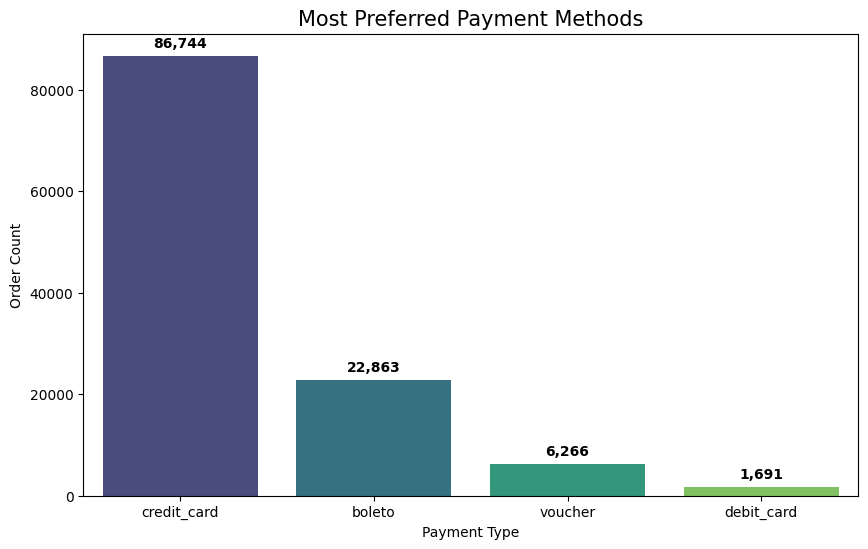

In [180]:
# 1- Calculating the number of orders for each payment type
payment_counts = payment_sales['payment_type'].value_counts().reset_index()
payment_counts.columns = ['Payment Type', 'Order Count']

plt.figure(figsize=(10, 6))

ax = sns.barplot(data=payment_counts, x='Payment Type', y='Order Count', hue='Payment Type', palette='viridis', legend=False)

# Data Label
for p in ax.patches:
    height = p.get_height()
    if height > 0:  
        ax.annotate(format(height, ',.0f'), 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points', 
                    fontweight='bold')

plt.title('Most Preferred Payment Methods', fontsize=15)
plt.show()

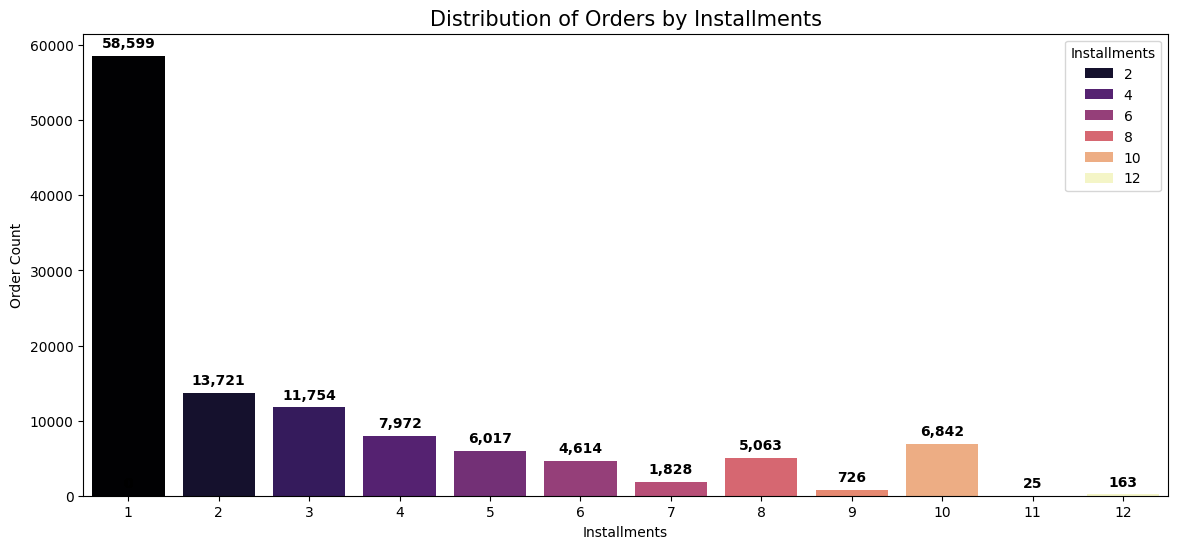

In [181]:
#2- Installment distribution account

installments_counts = payment_sales['payment_installments'].value_counts().sort_index().reset_index()
installments_counts.columns = ['Installments', 'Order Count']

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=installments_counts.head(12), x='Installments', y='Order Count', hue="Installments" , palette='magma')

for p in ax.patches:
    ax.annotate(format(p.get_height(), ',.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.title('Distribution of Orders by Installments', fontsize=15)
plt.show()

In [182]:
# Checking orders where the payment is less than the price
check_payments = payment_sales[payment_sales['payment_value'] < payment_sales['price']]

# Show a sample of these orders with columns explaining the reason
print(check_payments[['order_id', 'price', 'payment_value', 'payment_type', 'payment_sequential','payment_installments']].head(10))

                             order_id   price  payment_value payment_type  \
0    e481f51cbdc54678b7cc49136f2d6af7   29.99          18.12  credit_card   
1    e481f51cbdc54678b7cc49136f2d6af7   29.99           2.00      voucher   
2    e481f51cbdc54678b7cc49136f2d6af7   29.99          18.59      voucher   
12   e69bfb5eb88e0ed6a785585b27e16dbf  149.99           8.34  credit_card   
23   83018ec114eee8641c97e08f7b4e926f   76.00          62.15      voucher   
24   83018ec114eee8641c97e08f7b4e926f   76.00          24.86      voucher   
25   83018ec114eee8641c97e08f7b4e926f   76.00           5.96  credit_card   
97   634e8f4c0f6744a626f77f39770ac6aa  219.00           7.08  credit_card   
120  f7959f8385f34c4f645327465a1c9fc4   17.90           6.83  credit_card   
201  b2bd1f09c1b8a4a36940f6f6e49d5dec  199.00          29.13      voucher   

     payment_sequential  payment_installments  
0                     1                     1  
1                     3                     1  
2       

In [183]:
#1. We consolidate payments for each order to eliminate duplication.

order_payments_total = payment_sales.groupby('order_id').agg({
    'price': 'first',             
    'freight_value': 'first',      
    'payment_value': 'sum',       
    'payment_installments': 'max' 
}).reset_index()

order_payments_total['total_order_cost'] = order_payments_total['price'] + order_payments_total['freight_value']

print(order_payments_total[['order_id', 'total_order_cost', 'payment_value']].head())

                           order_id  total_order_cost  payment_value
0  00010242fe8c5a6d1ba2dd792cb16214             72.19          72.19
1  00018f77f2f0320c557190d7a144bdd3            259.83         259.83
2  000229ec398224ef6ca0657da4fc703e            216.87         216.87
3  00024acbcdf0a6daa1e931b038114c75             25.78          25.78
4  00042b26cf59d7ce69dfabb4e55b4fd9            218.04         218.04


In [184]:
# the last merge it's between payment sales and sellers to track staff performacne 

sales_three = payment_sales.copy()

seller_sales = pd.merge(sales_three, sellers, on= "seller_id", how= "inner")

# let's check data (seller_sales) quality report

full_data_quality_report(seller_sales)

========== DATA QUALITY REPORT ==========

1️⃣➡️ Missing Values:
                               Missing Values  Percentage %
order_delivered_customer_date            2565          2.18
order_delivered_carrier_date             1245          1.06
order_approved_at                          15          0.01 

2️⃣➡️ Data Types & Summary:
                      Column Name       Data Type  Unique Values  \
0                        order_id          object          98641   
1                     customer_id          object          98641   
2                    order_status          object              7   
3        order_purchase_timestamp  datetime64[ns]          98087   
4               order_approved_at  datetime64[ns]          90154   
5    order_delivered_carrier_date  datetime64[ns]          81000   
6   order_delivered_customer_date  datetime64[ns]          95639   
7   order_estimated_delivery_date  datetime64[ns]            449   
8                   order_item_id           int64    

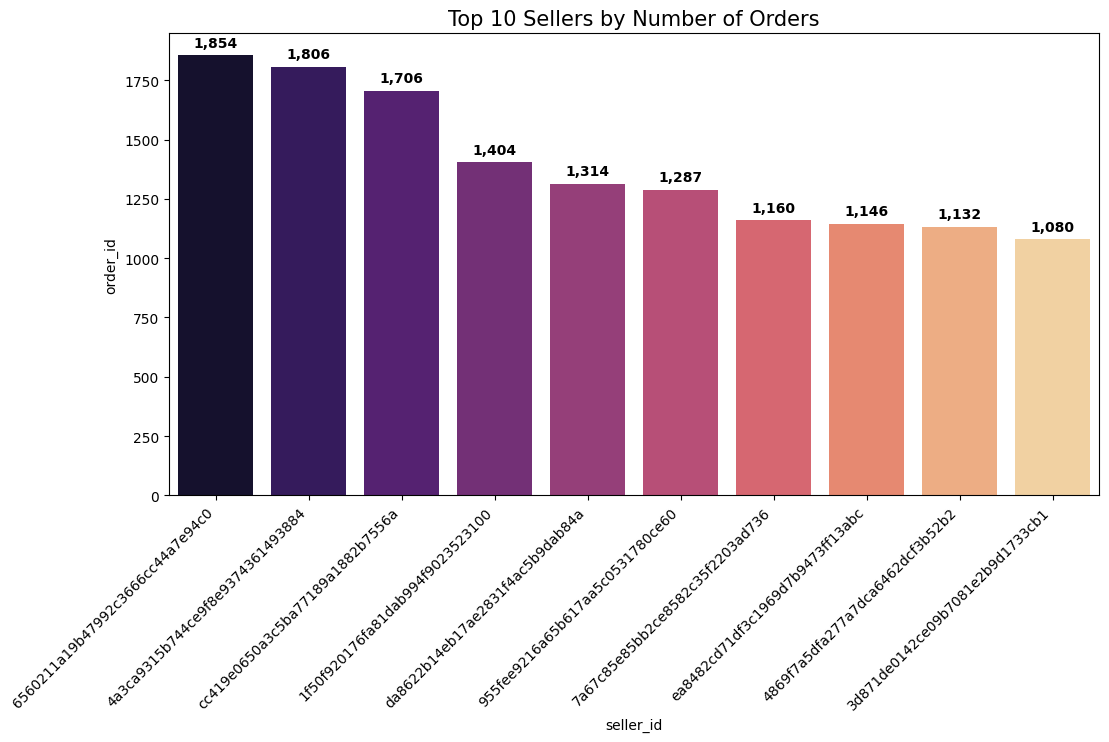

                             seller_id  order_id  payment_value
1235  6560211a19b47992c3666cc44a7e94c0      1854      179657.75
881   4a3ca9315b744ce9f8e9374361493884      1806      301245.27
2481  cc419e0650a3c5ba77189a1882b7556a      1706      141309.58
368   1f50f920176fa81dab994f9023523100      1404      290253.42
2643  da8622b14eb17ae2831f4ac5b9dab84a      1314      272219.32
1824  955fee9216a65b617aa5c0531780ce60      1287      236322.30
1505  7a67c85e85bb2ce8582c35f2203ad736      1160      169030.80
2836  ea8482cd71df3c1969d7b9473ff13abc      1146       61672.81
857   4869f7a5dfa277a7dca6462dcf3b52b2      1132      264166.12
731   3d871de0142ce09b7081e2b9d1733cb1      1080      131982.15


In [185]:
# EDA proccess

#1- Tot 10 employees by total orders

top_sellers = seller_sales.groupby('seller_id').agg({
    'order_id': 'nunique',
    'payment_value': 'sum'
}).reset_index()


top_10_sellers = top_sellers.sort_values(by='order_id', ascending=False).head(10)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top_10_sellers, x='seller_id', y='order_id', hue='seller_id', palette='magma', legend=False)

for p in ax.patches:
    ax.annotate(format(p.get_height(), ',.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.title('Top 10 Sellers by Number of Orders', fontsize=15)
plt.xticks(rotation=45, ha='right') 
plt.show()


print(top_10_sellers[['seller_id', 'order_id', 'payment_value']])

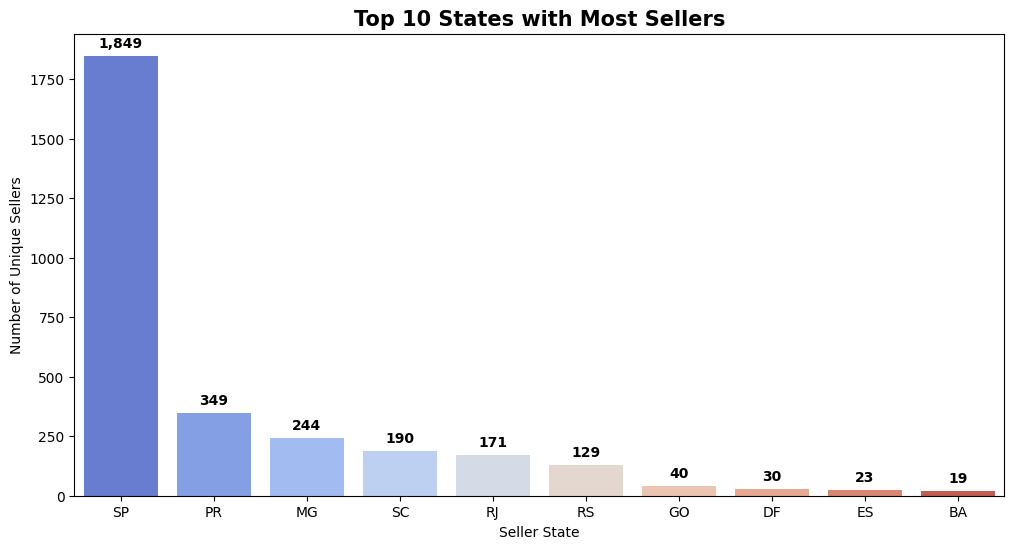

--- Summary: Top 10 Seller States & Revenue ---
   seller_state  seller_id  payment_value
22           SP       1849    13367127.06
15           PR        349     1844086.66
8            MG        244     1564497.92
20           SC        190      886745.47
16           RJ        171     1098242.23
19           RS        129      560236.38
6            GO         40      112183.09
4            DF         30      137784.98
5            ES         23       78839.53
2            BA         19      367899.46


In [186]:
# Top 10 States with the Most Sellers and Their Total Sales 

state_sellers = seller_sales.groupby('seller_state').agg({
    'seller_id': 'nunique',
    'payment_value': 'sum'
}).reset_index()

top_10_states_sellers = state_sellers.sort_values(by='seller_id', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6)) 

sns.barplot(data=top_10_states_sellers, x='seller_state', y='seller_id', 
            hue="seller_state", palette='coolwarm', legend=False, ax=ax)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(format(height, ',.0f'), 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points', 
                    fontweight='bold')

ax.set_title('Top 10 States with Most Sellers', fontsize=15, fontweight='bold')
ax.set_xlabel('Seller State')
ax.set_ylabel('Number of Unique Sellers')

plt.show()

print("--- Summary: Top 10 Seller States & Revenue ---")
print(top_10_states_sellers[['seller_state', 'seller_id', 'payment_value']])